In [1]:
# =========================================
# 1. IMPORT
# =========================================

import os
import json
import shutil
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


2026-05-29 08:44:01.775619: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780044241.992903      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780044242.055946      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780044242.601634      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780044242.601673      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780044242.601676      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
# =========================================
# 2. CONFIG
# =========================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATASET_PATH = "/kaggle/input/datasets/kimlonkkk/data10k-v2/split_dataset_backup_10k_v2"

IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 40

MODEL_NAME = "ViT_Scratch"
OUT_DIR = f"/kaggle/working/{MODEL_NAME}_results"

os.makedirs(OUT_DIR, exist_ok=True)

AUTOTUNE = tf.data.AUTOTUNE


In [3]:
# =========================================
# 3. LOAD DATASET
# =========================================

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "train"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "val"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATASET_PATH, "test"),
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

CLASS_NAMES = train_ds.class_names
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Num classes:", NUM_CLASSES)


Found 6890 files belonging to 5 classes.


I0000 00:00:1779967104.923436      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779967104.929454      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 1475 files belonging to 5 classes.
Found 1482 files belonging to 5 classes.
Classes: ['blight', 'common_rust', 'gray_spot', 'healthy', 'not_corn_leaf']
Num classes: 5


In [4]:
# =========================================
# 4. NORMALIZE + PREFETCH
# =========================================

normalization_layer = layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)


In [5]:
# =========================================
# 5. DATA AUGMENTATION
# =========================================
# Dataset của bạn đã có xoay/lật/chỉnh sáng sẵn,
# nên augmentation ở đây để rất nhẹ.

data_augmentation = tf.keras.Sequential(
    [
        layers.RandomZoom(0.03),
        layers.RandomTranslation(0.02, 0.02),
    ],
    name="data_augmentation"
)


In [6]:
# =========================================
# 6. PATCH LAYER
# =========================================

class Patches(layers.Layer):
    def __init__(self, patch_size, **kwargs):
        super().__init__(**kwargs)
        self.patch_size = patch_size

    def call(self, images):
        batch_size = tf.shape(images)[0]

        patches = tf.image.extract_patches(
            images=images,
            sizes=[1, self.patch_size, self.patch_size, 1],
            strides=[1, self.patch_size, self.patch_size, 1],
            rates=[1, 1, 1, 1],
            padding="VALID"
        )

        patch_dims = tf.shape(patches)[-1]

        patches = tf.reshape(
            patches,
            [batch_size, -1, patch_dims]
        )

        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config


In [7]:
# =========================================
# 7. PATCH ENCODER
# =========================================

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim, **kwargs):
        super().__init__(**kwargs)
        self.num_patches = num_patches
        self.projection_dim = projection_dim

        self.projection = layers.Dense(projection_dim)

        self.position_embedding = layers.Embedding(
            input_dim=num_patches,
            output_dim=projection_dim
        )

    def call(self, patch):
        positions = tf.range(
            start=0,
            limit=self.num_patches,
            delta=1
        )

        encoded = self.projection(patch) + self.position_embedding(positions)

        return encoded

    def get_config(self):
        config = super().get_config()
        config.update(
            {
                "num_patches": self.num_patches,
                "projection_dim": self.projection_dim
            }
        )
        return config


In [8]:
# =========================================
# 8. MLP HELPER
# =========================================

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(
            units,
            activation=tf.nn.gelu
        )(x)

        x = layers.Dropout(dropout_rate)(x)

    return x


In [9]:
# =========================================
# 9. BUILD ViT MODEL
# =========================================

PATCH_SIZE = 32
NUM_PATCHES = (IMG_SIZE // PATCH_SIZE) ** 2

PROJECTION_DIM = 32
NUM_HEADS = 2
TRANSFORMER_LAYERS = 4

TRANSFORMER_UNITS = [
    PROJECTION_DIM * 2,
    PROJECTION_DIM
]

MLP_HEAD_UNITS = [128]


def build_vit_model():
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x = data_augmentation(inputs)

    patches = Patches(
        PATCH_SIZE,
        name="patches"
    )(x)

    encoded_patches = PatchEncoder(
        NUM_PATCHES,
        PROJECTION_DIM,
        name="patch_encoder"
    )(patches)

    for i in range(TRANSFORMER_LAYERS):
        x1 = layers.LayerNormalization(
            epsilon=1e-6,
            name=f"ln_1_block_{i+1}"
        )(encoded_patches)

        attention_output = layers.MultiHeadAttention(
            num_heads=NUM_HEADS,
            key_dim=PROJECTION_DIM,
            dropout=0.1,
            name=f"mha_block_{i+1}"
        )(x1, x1)

        x2 = layers.Add(name=f"skip_1_block_{i+1}")(
            [attention_output, encoded_patches]
        )

        x3 = layers.LayerNormalization(
            epsilon=1e-6,
            name=f"ln_2_block_{i+1}"
        )(x2)

        x3 = mlp(
            x3,
            hidden_units=TRANSFORMER_UNITS,
            dropout_rate=0.1
        )

        encoded_patches = layers.Add(name=f"skip_2_block_{i+1}")(
            [x3, x2]
        )

    representation = layers.LayerNormalization(
        epsilon=1e-6,
        name="encoder_norm"
    )(encoded_patches)

    representation = layers.Flatten(name="flatten")(representation)

    representation = layers.Dropout(0.3, name="head_dropout")(representation)

    features = mlp(
        representation,
        hidden_units=MLP_HEAD_UNITS,
        dropout_rate=0.3
    )

    outputs = layers.Dense(
        NUM_CLASSES,
        activation="softmax",
        name="classification_head"
    )(features)

    model = Model(
        inputs=inputs,
        outputs=outputs,
        name=MODEL_NAME
    )

    return model


model = build_vit_model()
model.summary()


Model: "ViT_Scratch"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ data_augmentation   │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patches (Patches)   │ (None, None,      │          0 │ data_augmentatio… │
│                     │ 3072)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ patch_encoder       │ (None, 49, 32)    │     99,904 │ patches[0][0]     │
│ (PatchEncoder)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_1_block_1        │ (None, 49, 32)    │         64 │ patch_encoder[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha_block_1         │ (None, 49, 32)    │      8,416 │ ln_1_block_1[0][… │
│ (MultiHeadAttentio… │                   │            │ ln_1_block_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_1_block_1      │ (None, 49, 32)    │          0 │ mha_block_1[0][0… │
│ (Add)               │                   │            │ patch_encoder[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_2_block_1        │ (None, 49, 32)    │         64 │ skip_1_block_1[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 49, 64)    │      2,112 │ ln_2_block_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 49, 64)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 49, 32)    │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 49, 32)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_2_block_1      │ (None, 49, 32)    │          0 │ dropout_2[0][0],  │
│ (Add)               │                   │            │ skip_1_block_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_1_block_2        │ (None, 49, 32)    │         64 │ skip_2_block_1[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mha_block_2         │ (None, 49, 32)    │      8,416 │ ln_1_block_2[0][… │
│ (MultiHeadAttentio… │                   │            │ ln_1_block_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip_1_block_2      │ (None, 49, 32)    │          0 │ mha_block_2[0][0… │
│ (Add)               │                   │            │ skip_2_block_1[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ln_2_block_2        │ (None, 49, 32)    │         64 │ skip_1_block_2[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 49, 64)    │      2,112 │ ln_2_block_2[0][… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 352,389 (1.34 MB)

 Trainable params: 352,389 (1.34 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# =========================================
# 10. COMPILE
# =========================================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [11]:
# =========================================
# 11. CALLBACKS
# =========================================

checkpoint = ModelCheckpoint(
    filepath=f"{OUT_DIR}/{MODEL_NAME}_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

callbacks = [
    checkpoint,
    earlystop,
    reduce_lr
]


In [12]:
# =========================================
# 12. TRAIN
# =========================================

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/40
216/216 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.3328 - loss: 1.6079
Epoch 1: val_accuracy improved from None to 0.46983, saving model to /kaggle/working/ViT_Scratch_results/ViT_Scratch_best.keras

Epoch 1: finished saving model to /kaggle/working/ViT_Scratch_results/ViT_Scratch_best.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 29s 63ms/step - accuracy: 0.4030 - loss: 1.3350 - val_accuracy: 0.4698 - val_loss: 1.0716 - learning_rate: 0.0010
Epoch 2/40
214/216 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5508 - loss: 1.0027
Epoch 2: val_accuracy improved from 0.46983 to 0.75186, saving model to /kaggle/working/ViT_Scratch_results/ViT_Scratch_best.keras

Epoch 2: finished saving model to /kaggle/working/ViT_Scratch_results/ViT_Scratch_best.keras
216/216 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.6032 - loss: 0.8922 - val_accuracy: 0.7519 - val_loss: 0.5983 - learning_rate: 0.0010
Epoch 3/40
215/216 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.7304 - loss: 0.6374
Epoch 

In [13]:
# =========================================
# 13. SAVE HISTORY
# =========================================

history_df = pd.DataFrame(history.history)

history_path = f"{OUT_DIR}/history.csv"
history_df.to_csv(history_path, index=False)

print("Saved:", history_path)
history_df.head()


Saved: /kaggle/working/ViT_Scratch_results/history.csv


,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.403048,1.335000,0.469831,1.071582,0.001
1,0.603193,0.892226,0.751864,0.598285,0.001
2,0.754427,0.594830,0.828475,0.416211,0.001
3,0.833817,0.415266,0.847458,0.450138,0.001
4,0.860668,0.359824,0.903729,0.294908,0.001


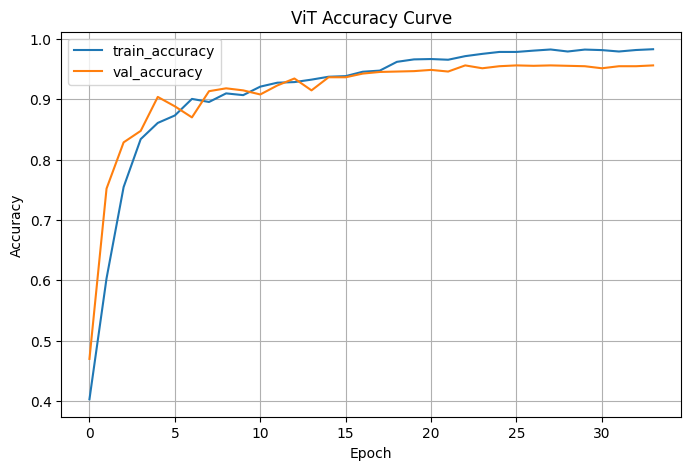

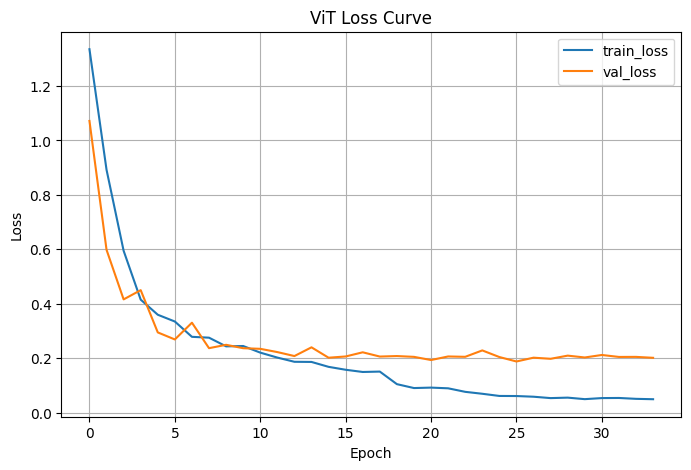

In [14]:
# =========================================
# 14. LEARNING CURVES
# =========================================

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="train_accuracy")
plt.plot(history.history["val_accuracy"], label="val_accuracy")
plt.title("ViT Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUT_DIR}/accuracy_curve.png", dpi=150, bbox_inches="tight")
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("ViT Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(f"{OUT_DIR}/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()


In [15]:
# =========================================
# 15. EVALUATE TEST SET
# =========================================

test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)


47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.9420 - loss: 0.2171
Test Loss: 0.21711626648902893
Test Accuracy: 0.9419702887535095


In [16]:
# =========================================
# 16. PREDICT TEST SET
# =========================================

y_true = []

for _, y_batch in test_ds:
    y_true.extend(y_batch.numpy())

y_true = np.array(y_true)

pred_probs = model.predict(test_ds)
y_pred = np.argmax(pred_probs, axis=1)

print("y_true:", y_true.shape)
print("y_pred:", y_pred.shape)


47/47 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step
y_true: (1482,)
y_pred: (1482,)


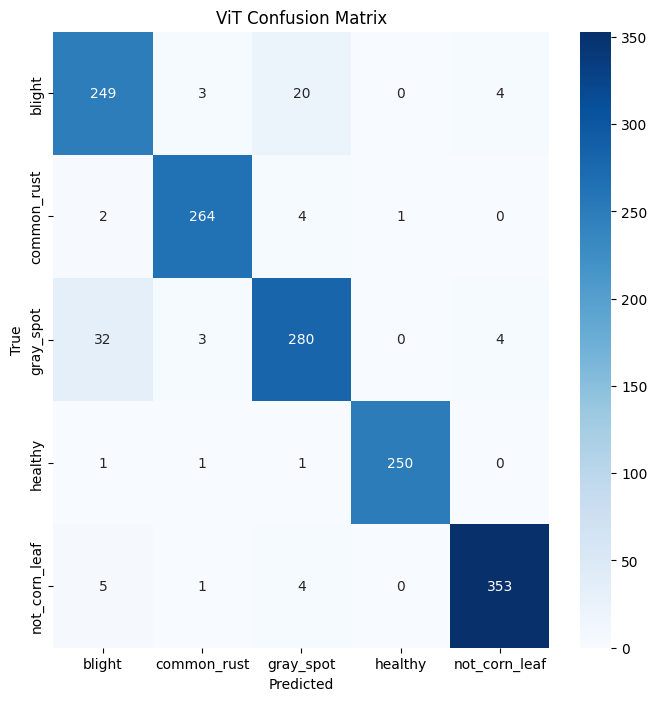

Saved: /kaggle/working/ViT_Scratch_results/confusion_matrix.png


In [17]:
# =========================================
# 17. CONFUSION MATRIX
# =========================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("ViT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

cm_path = f"{OUT_DIR}/confusion_matrix.png"
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", cm_path)


In [18]:
# =========================================
# 18. CLASSIFICATION REPORT
# =========================================

report_text = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES
)

print(report_text)

report_dict = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

report_path = f"{OUT_DIR}/classification_report.csv"
report_df.to_csv(report_path)

print("Saved:", report_path)
report_df


               precision    recall  f1-score   support

       blight       0.86      0.90      0.88       276
  common_rust       0.97      0.97      0.97       271
    gray_spot       0.91      0.88      0.89       319
      healthy       1.00      0.99      0.99       253
not_corn_leaf       0.98      0.97      0.98       363

     accuracy                           0.94      1482
    macro avg       0.94      0.94      0.94      1482
 weighted avg       0.94      0.94      0.94      1482

Saved: /kaggle/working/ViT_Scratch_results/classification_report.csv


,precision,recall,f1-score,support
blight,0.861592,0.902174,0.881416,276.00000
common_rust,0.970588,0.974170,0.972376,271.00000
gray_spot,0.906149,0.877743,0.891720,319.00000
healthy,0.996016,0.988142,0.992063,253.00000
not_corn_leaf,0.977839,0.972452,0.975138,363.00000
accuracy,0.941970,0.941970,0.941970,0.94197
macro avg,0.942437,0.942936,0.942543,1482.00000
weighted avg,0.942536,0.941970,0.942112,1482.00000


In [19]:
# =========================================
# 19. SAVE METRICS
# =========================================

metrics = {
    "model_name": MODEL_NAME,
    "test_loss": float(test_loss),
    "test_accuracy": float(test_acc),
    "classes": CLASS_NAMES,
    "img_size": IMG_SIZE,
    "batch_size": BATCH_SIZE,
    "patch_size": PATCH_SIZE,
    "num_patches": NUM_PATCHES,
    "projection_dim": PROJECTION_DIM,
    "num_heads": NUM_HEADS,
    "transformer_layers": TRANSFORMER_LAYERS
}

metrics_path = f"{OUT_DIR}/metrics.json"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4, ensure_ascii=False)

print("Saved:", metrics_path)


Saved: /kaggle/working/ViT_Scratch_results/metrics.json


In [20]:
# =========================================
# 20. ZIP RESULTS
# =========================================

zip_path = f"/kaggle/working/{MODEL_NAME}_results.zip"

shutil.make_archive(
    zip_path.replace(".zip", ""),
    "zip",
    OUT_DIR
)

print("Saved:", zip_path)


Saved: /kaggle/working/ViT_Scratch_results.zip


In [2]:
# =========================================
# 21. OPTIONAL - UPLOAD IMAGE FROM COMPUTER AND TEST
# =========================================

import io
from PIL import Image
from ipywidgets import FileUpload
from IPython.display import display

uploader = FileUpload(
    accept="image/*",
    multiple=False
)

display(uploader)


FileUpload(value=(), accept='image/*', description='Upload')

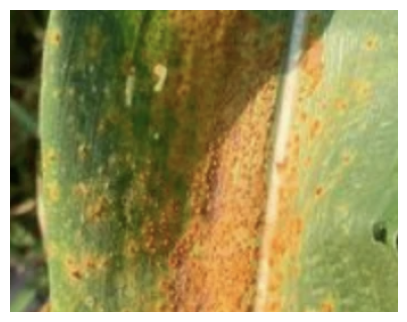

NameError: name 'IMG_SIZE' is not defined

In [4]:
# Run this cell after choosing an image above.

uploaded = uploader.value[0]

img = Image.open(
    io.BytesIO(uploaded["content"])
).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.show()

img_resized = img.resize((IMG_SIZE, IMG_SIZE))

x = np.array(img_resized).astype("float32") / 255.0
x = np.expand_dims(x, axis=0)

pred = model.predict(x)[0]

pred_idx = int(np.argmax(pred))
confidence = float(pred[pred_idx])

print("Prediction:", CLASS_NAMES[pred_idx])
print("Confidence:", f"{confidence:.4f}")

print("\nAll probabilities:")
for cls, prob in zip(CLASS_NAMES, pred):
    print(f"{cls:15s}: {prob:.4f}")
